##############################################################################
##############################################################################
#                              SERIES TEMPORAIS                              #
##############################################################################
##############################################################################

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np

In [50]:
# Leitura da base

# Lendo a base de dados
basepetr4 = pd.read_excel("basepetr4.xlsx")

# Lendo apenas as primeiras linhas das variaveis
print(basepetr4.head())

# Buscando a cotacoes de fechamento apenas da PETR4 e chamando os dados em petr4
petr4 = basepetr4['fechamento']

# Lendo os dados iniciais brutos
print(petr4.head())

                 Date  abertura  maxima  minimo  fechamento    volume
0 2020-01-02 16:56:00     30.51   30.70   30.31       30.70  37774500
1 2020-01-03 00:00:00     30.88   31.24   30.45       30.45  71595600
2 2020-01-07 16:56:00     30.82   30.88   30.47       30.69  32822000
3 2020-01-08 16:56:00     30.69   30.77   30.24       30.50  48215600
4 2020-01-09 16:56:00     30.47   30.62   30.25       30.40  36102700
0    30.70
1    30.45
2    30.69
3    30.50
4    30.40
Name: fechamento, dtype: float64


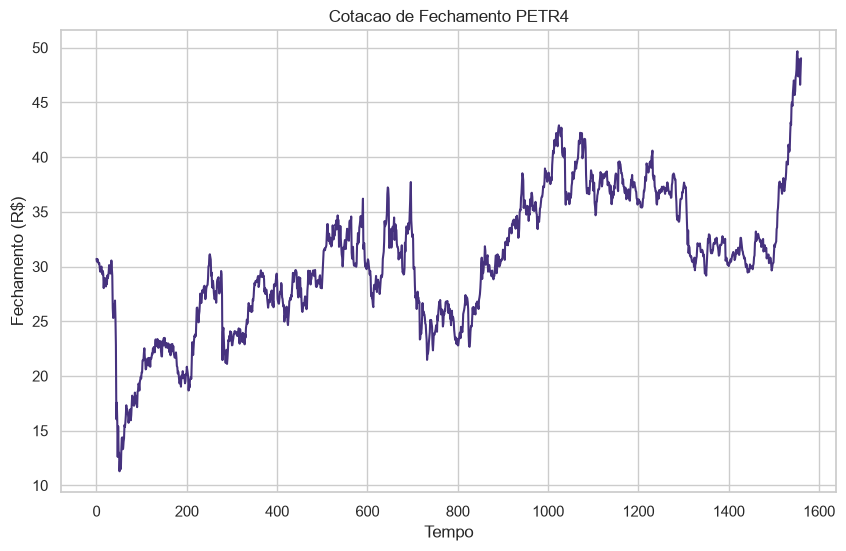

In [51]:
# Plotando o grafico bruto (selecione todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(petr4)
plt.title('Cotacao de Fechamento PETR4')
plt.xlabel('Tempo')
plt.ylabel('Fechamento (R$)')
plt.show()

1561


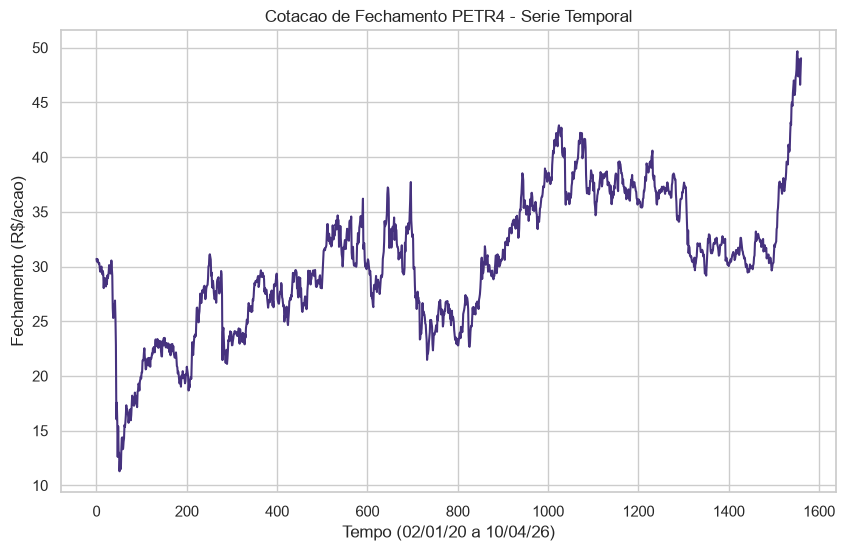

In [52]:
# Definindo petr4 como uma serie temporal
petr4_ts = pd.Series(petr4.values, index=pd.to_datetime(basepetr4['Date']))

# Quantas cotacoes tenho?
print(len(petr4_ts))

# In[4]: Grafico como serie de tempo usando Plotly (Selecione todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(petr4)
plt.title('Cotacao de Fechamento PETR4 - Serie Temporal')
plt.xlabel('Tempo (02/01/20 a 10/04/26)')
plt.ylabel('Fechamento (R$/acao)')
plt.show()

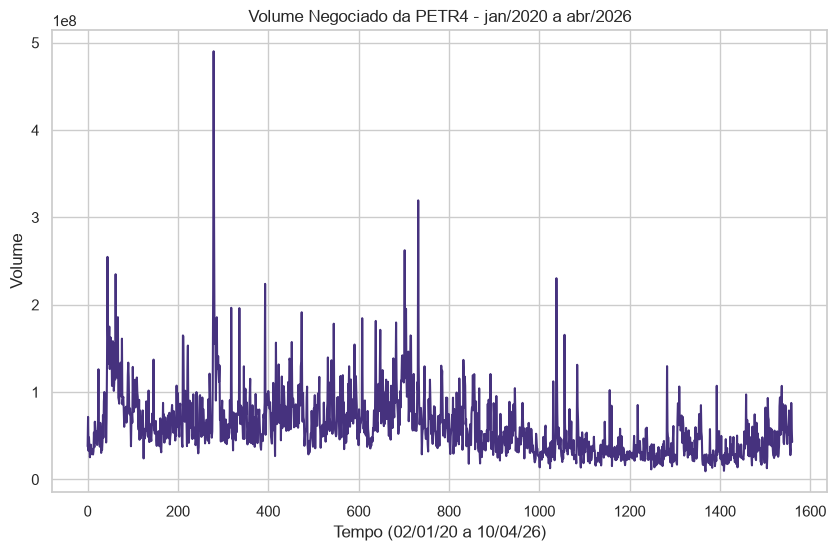

In [53]:
# In[5]: Considerando as demais informacoes da base de dados basepetr4
volume = basepetr4['volume']
minimo = basepetr4['minimo']
abertura = basepetr4['abertura']

# In[6]: Colocando os dados em forma de uma matriz com todos os dados no conjunto
# chamado dados1
dados1 = pd.concat([petr4, volume, minimo, abertura], axis=1)
dados1.columns = ['Fechamento R$', 'Volume Financ. Neg', 'Mi­nimo R$', 
                  'Abertura R$']

# In[7]: Plotando os graficos (selecione todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(dados1['Volume Financ. Neg'])
plt.title('Volume Negociado da PETR4 - jan/2020 a abr/2026')
plt.xlabel('Tempo (02/01/20 a 10/04/26)')
plt.ylabel('Volume')
plt.show()

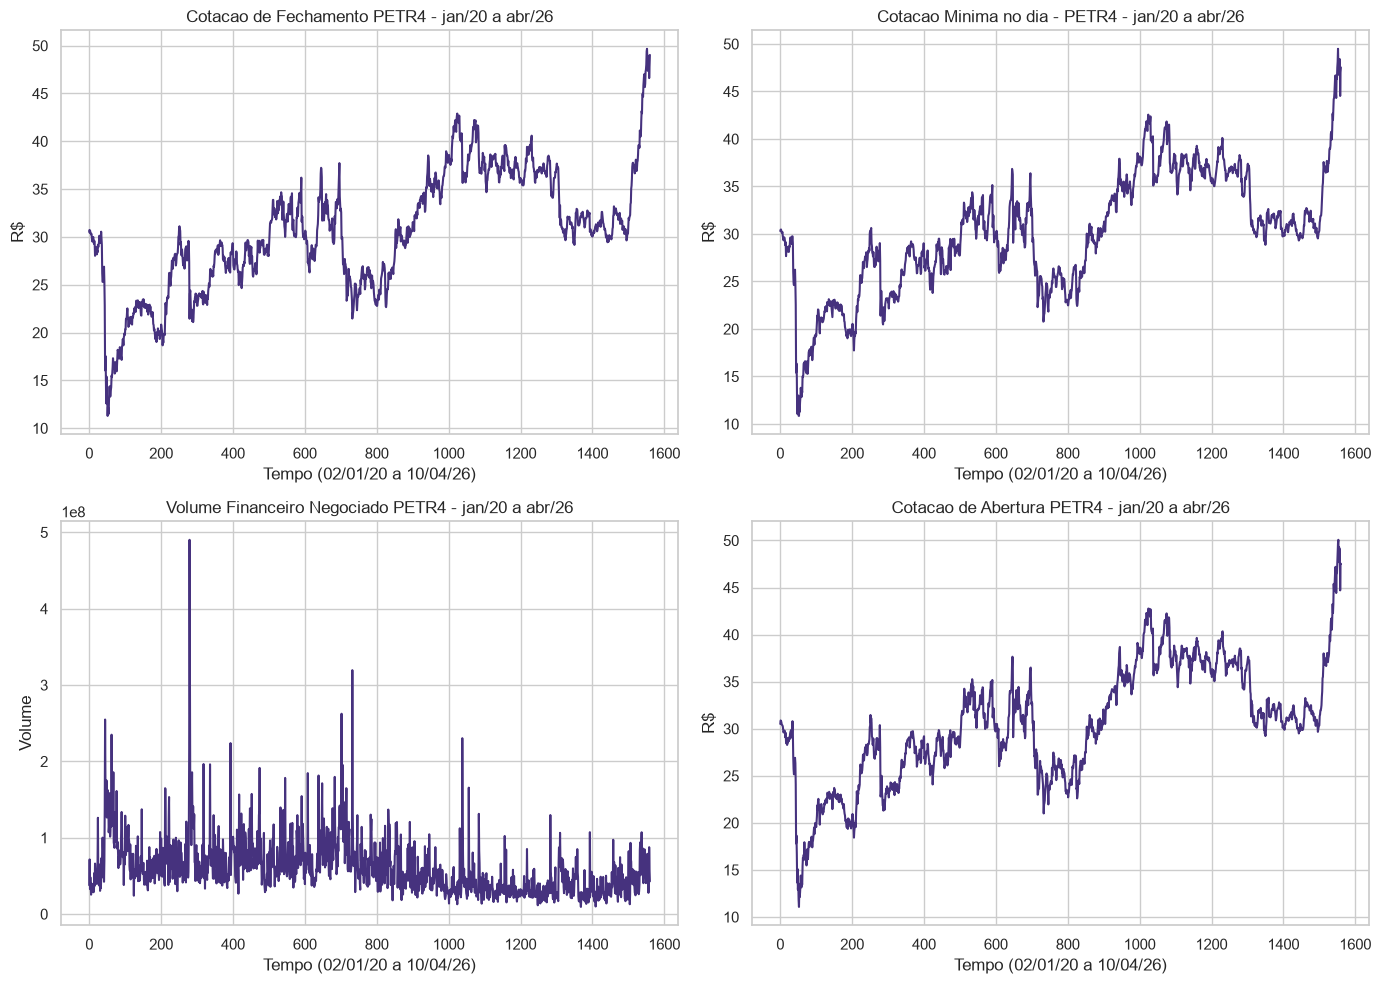

In [54]:
# In[8]: Construindo uma janela com 4 graficos - Selecione todos os comandos
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(dados1['Fechamento R$'])
axs[0, 0].set_title('Cotacao de Fechamento PETR4 - jan/20 a abr/26')
axs[0, 0].set_xlabel('Tempo (02/01/20 a 10/04/26)')
axs[0, 0].set_ylabel('R$')

axs[0, 1].plot(dados1['Mi­nimo R$'])
axs[0, 1].set_title('Cotacao Mi­nima no dia - PETR4 - jan/20 a abr/26')
axs[0, 1].set_xlabel('Tempo (02/01/20 a 10/04/26)')
axs[0, 1].set_ylabel('R$')

axs[1, 0].plot(dados1['Volume Financ. Neg'])
axs[1, 0].set_title('Volume Financeiro Negociado PETR4 - jan/20 a abr/26')
axs[1, 0].set_xlabel('Tempo (02/01/20 a 10/04/26)')
axs[1, 0].set_ylabel('Volume')

axs[1, 1].plot(dados1['Abertura R$'])
axs[1, 1].set_title('Cotacao de Abertura PETR4 - jan/20 a abr/26')
axs[1, 1].set_xlabel('Tempo (02/01/20 a 10/04/26)')
axs[1, 1].set_ylabel('R$')

plt.tight_layout()
plt.show()

In [55]:
# In[9]: Mostrar google planilhas

############## Como forma alternativa, pode-se baixar esses dados diretamente
# do yfinance
##############
#pip install yfinance
import yfinance as yf

# Especifica o ticker do ativo desejado (neste caso, PETR4)
ticker = "PETR4.SA"

# Define o intervalo de datas desejado
start_date = "2022-01-01"
end_date = "2026-04-10"

# Obtemos os dados do Yahoo Finance
data = yf.download(ticker, start=start_date, end=end_date)

# Exibe os primeiros registros dos dados obtidos
print(data.head())

# Salva os dados em um arquivo CSV
csv_file_path = "dados_petroleo.csv"
data.to_csv(csv_file_path)

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open    Volume
Ticker      PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA
Date                                                        
2022-01-03  9.664045  9.707233  9.478007  9.481329  52704700
2022-01-04  9.700589  9.767031  9.604247  9.687300  51739200
2022-01-05  9.325190  9.723844  9.282002  9.697267  78459800
2022-01-06  9.318545  9.517873  9.248781  9.398277  61163100
2022-01-07  9.361733  9.398277  9.242137  9.338479  47507600


In [56]:
# In[10]: Funcao para baixar dados do Yahoo Finance (Selecionar todos os comandos)
def obter_dados(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data

# In[11]: Funcao para plotar os 4 graficos (Selecionar todos os comandos)
def plotar_graficos(data):
    fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

    # Grafico 1: Abertura
    axs[0].plot(data['Open'], label='Abertura', color='blue')
    axs[0].set_ylabel('Abertura')

    # Grafico 2: Mi­nima
    axs[1].plot(data['Low'], label='Mi­nima', color='green')
    axs[1].set_ylabel('Minima')

    # Grafico 3: Maxima
    axs[2].plot(data['High'], label='Maxima', color='red')
    axs[2].set_ylabel('Maxima')

    # Grafico 4: Fechamento
    axs[3].plot(data['Close'], label='Fechamento', color='purple')
    axs[3].set_ylabel('Fechamento')

    axs[3].set_xlabel('Data')

    # Adiciona legenda
    axs[0].legend()
    axs[1].legend()
    axs[2].legend()
    axs[3].legend()

    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed


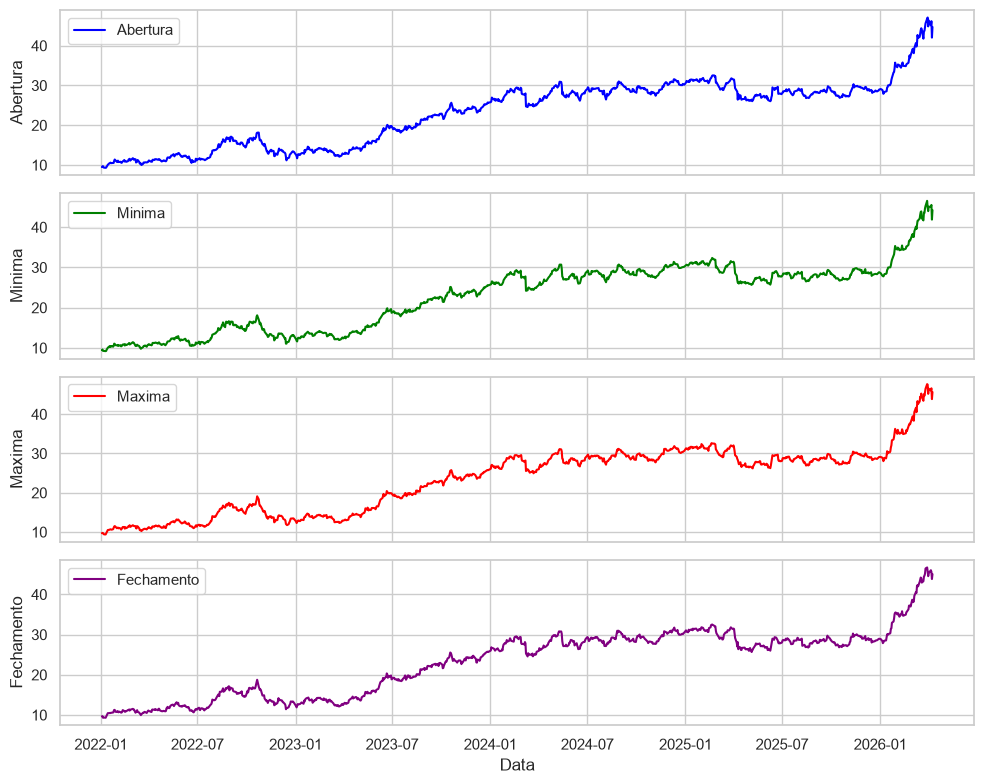

In [57]:
# In[12]: Define o ticker, data de inicio e data de fim
ticker = "PETR4.SA"
start_date = "2022-01-01"
end_date = "2026-04-10"

# In[13]: Obtem os dados do Yahoo Finance
dados = obter_dados(ticker, start_date, end_date)

# In[14]: Plota os 4 graficos
plotar_graficos(dados)

###############################################################################
### Trabalhando com a base de dados de Passageiros no Transporte Aereo - BR
###############################################################################


In [58]:
# Importando a base de dados
passageiros = pd.read_excel("passageiros.xlsx")

# Lendo a base de dados
print(passageiros.head())

# A base de dados tem duas colunas, e os passageiros transportados estao na 
# coluna 2
passag = passageiros.iloc[:, 1]

# Lendo apenas as primeiras linhas das variaveis
print(passag.head())

# Definindo o conjunto de dados passageiros como uma serie temporal
passag_ts = pd.Series(passag.values,
                      index=pd.to_datetime(passageiros.iloc[:, 0]))

        Data  passageiros
0 2011-01-01      8894294
1 2011-02-01      7212406
2 2011-03-01      8326063
3 2011-04-01      8365816
4 2011-05-01      8148295
0    8894294
1    7212406
2    8326063
3    8365816
4    8148295
Name: passageiros, dtype: int64


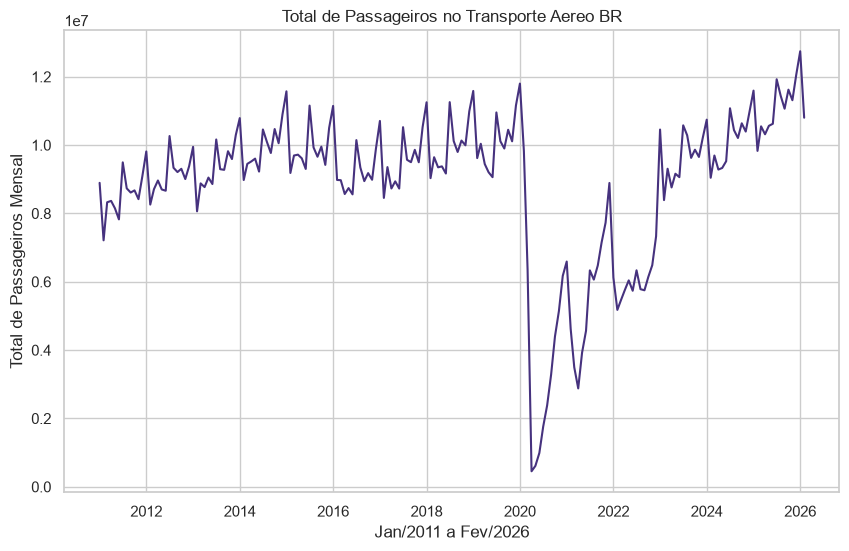

In [59]:
# In[16]: Fazendo o grafico (Selecionar todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(passag_ts)
plt.title("Total de Passageiros no Transporte Aereo BR")
plt.xlabel("Jan/2011 a Fev/2026")
plt.ylabel("Total de Passageiros Mensal")
plt.show()



###############################################################################
### Trabalhando com uma Serie Temporal da Receita Trimestral da AMBEV
###############################################################################


In [60]:
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# Importando a base de dados
ambev = pd.read_excel("ambev.xlsx")

# Lendo a base de dados
print(ambev.head())

# Ajustando a base de dados trimestrais acumulados da Receita Liquida 
# Operacional da AMBEV
# Definindo a serie temporal com frequencia trimestral
# ATENCAO: dependendo da versao do pandas usar freq='QE'

receita = pd.Series(ambev.iloc[:, 1].values, 
                    index=pd.date_range(start='2000-01-01', periods=len(ambev), 
                                        freq='QE'))


       Data   receita_ac  receita_t
0 2000-03-31     877.498    877.498
1 2000-06-30    1690.009    812.511
2 2000-09-30    3522.524   1832.515
3 2000-12-31    5250.345   1727.821
4 2001-03-31    1515.505   1515.505


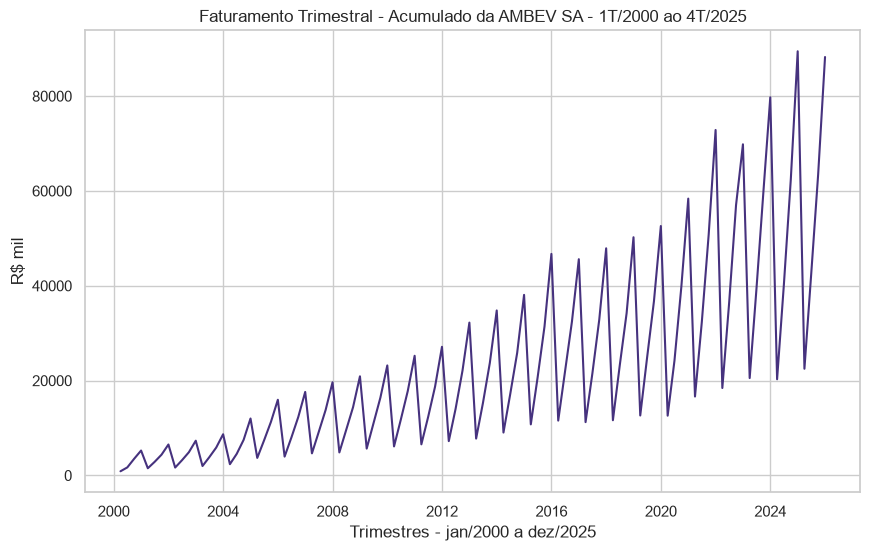

In [61]:
# In[18]: Plotando o grafico
plt.figure(figsize=(10, 6))
plt.plot(receita)
plt.title("Faturamento Trimestral - Acumulado da AMBEV SA - 1T/2000 ao 4T/2025")
plt.xlabel("Trimestres - jan/2000 a dez/2025")
plt.ylabel("R$ mil")
plt.grid(True)
plt.show()

###############################################################################
### Trabalhando com a base de dados das Manchas Solares
###############################################################################


In [62]:

# Importando a base de dados
manchas = pd.read_excel("manchas.xlsx")

# Transformar o data frame em serie de tempo (Selecionar todos os comandos)
sol = pd.Series(manchas['manchas'].values, 
                index=pd.date_range(start='1749-01-01',
                                    periods=len(manchas), freq='ME'))

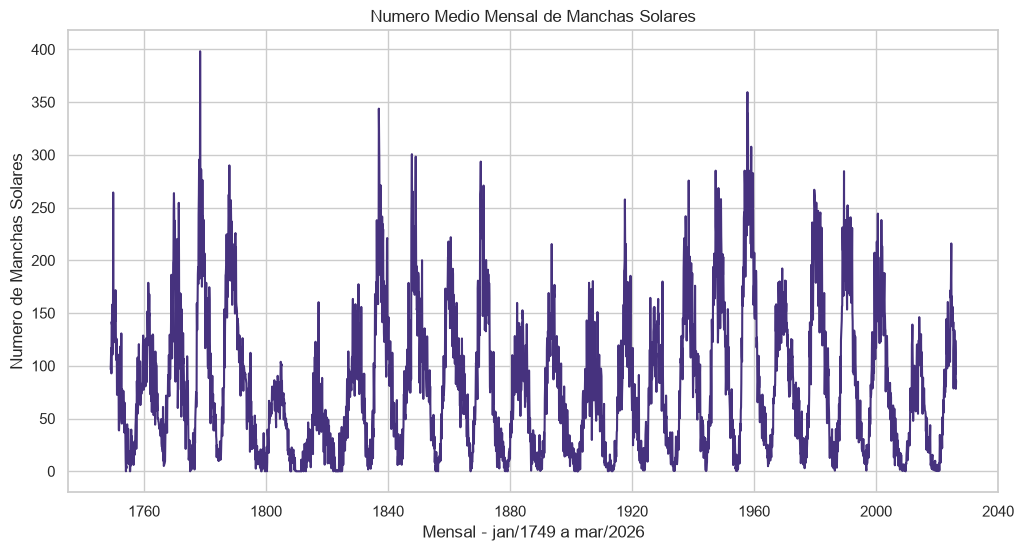

In [63]:
# In[20]: Plotando o grafico (Selecionar todos os comandos)
plt.figure(figsize=(12, 6))
plt.plot(sol)
plt.title("Numero Medio Mensal de Manchas Solares")
plt.xlabel("Mensal - jan/1749 a mar/2026")
plt.ylabel("Numero de Manchas Solares")
plt.grid(True)
plt.show()

In [64]:
# In[21]: Medidas das Estatisticas Descritivas da Serie Temporal
print("Resumo estatistico:")
print(sol.describe())
print("\nDesvio padrao:")
print(sol.std())
print("\nNumero de observacoes:")
print(len(sol))

Resumo estatistico:
count    3327.000000
mean       82.195642
std        67.615109
min         0.000000
25%        24.350000
50%        68.500000
75%       123.100000
max       398.200000
dtype: float64

Desvio padrao:
67.61510896652241

Numero de observacoes:
3327


In [65]:
# In[22]: Definir uma janela de tempo da Serie Temporal
sol1 = sol['1749-01-01':'1990-12-31']

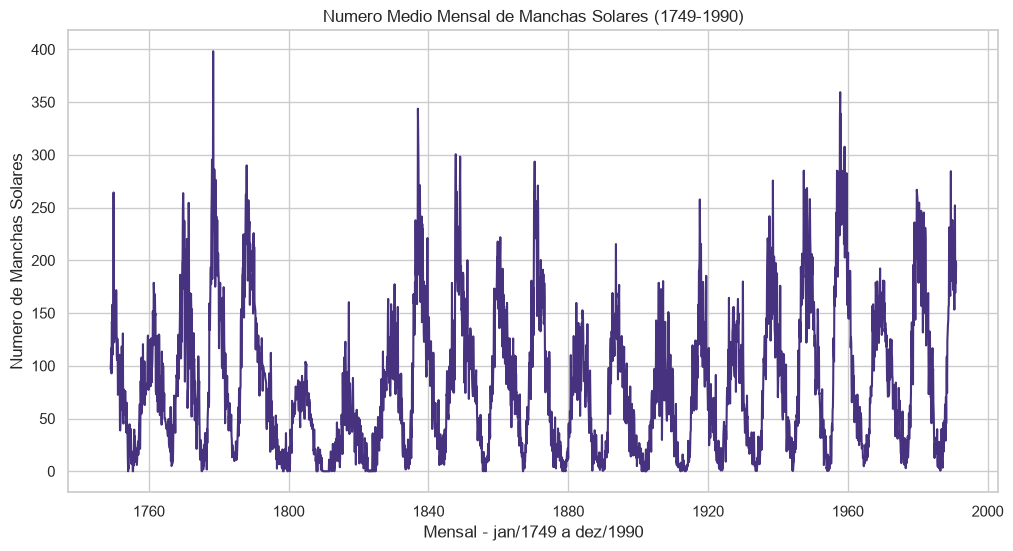

In [66]:
# In[23]: Plotando o grafico da janela de tempo (Selecionar todos os comandos)
plt.figure(figsize=(12, 6))
plt.plot(sol1)
plt.title("Numero Medio Mensal de Manchas Solares (1749-1990)")
plt.xlabel("Mensal - jan/1749 a dez/1990")
plt.ylabel("Numero de Manchas Solares")
plt.grid(True)
plt.show()


###############################################################################
### Trabalhando com a base de dados de Focos de Queimadas - INPE
### Fonte: https://terrabrasilis.dpi.inpe.br/queimadas/portal/
###############################################################################


In [67]:
# Importando a base de dados
queimadas = pd.read_excel("queimadas.xlsx")

# Transformar o data frame em serie de tempo (Selecionar todos os comandos)
queimad = pd.Series(queimadas['focos'].values, 
                index=pd.date_range(start='1999-01-01', 
                                    periods=len(queimadas), freq='ME'))

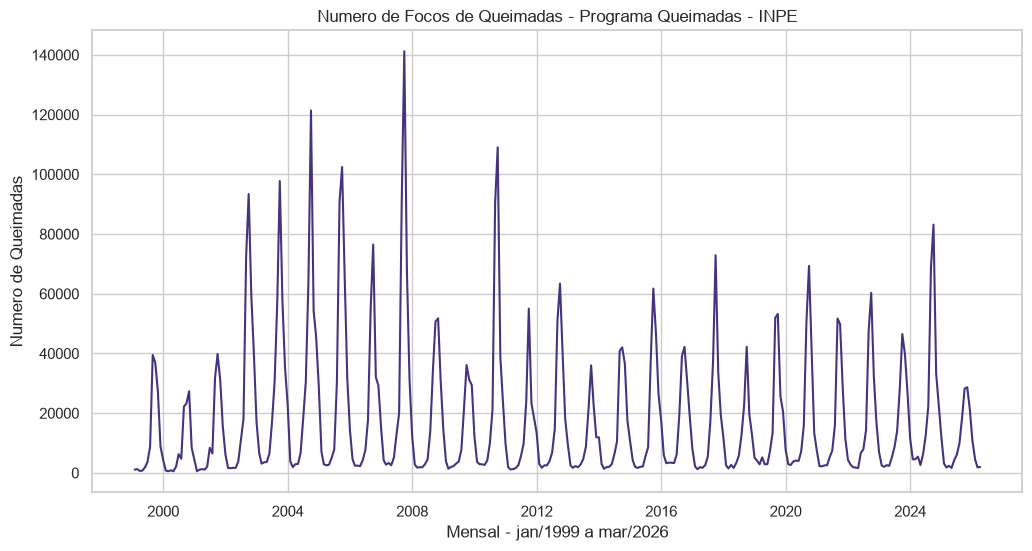

In [68]:
# In[25]: Plotando o grafico (Selecionar todos os comandos)
plt.figure(figsize=(12, 6))
plt.plot(queimad)
plt.title("Numero de Focos de Queimadas - Programa Queimadas - INPE")
plt.xlabel("Mensal - jan/1999 a mar/2026")
plt.ylabel("Numero de Queimadas")
plt.grid(True)
plt.show()

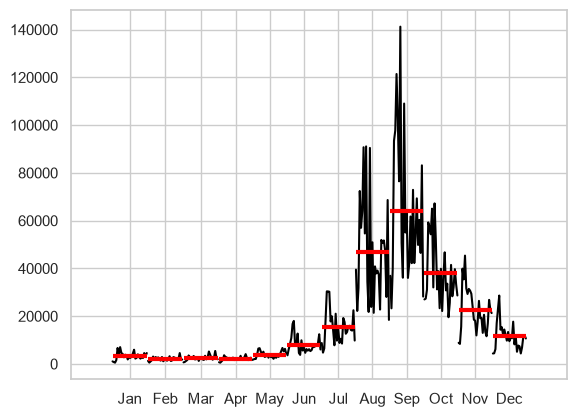

In [69]:
# In[25.1] Grafico das queimadas por mes
import statsmodels.api as sm

sm.graphics.tsa.month_plot(queimad)

plt.show()

###############################################################################
### Trabalhando com uma Serie Temporal de Numeros Aleatorios
###############################################################################


In [70]:
# Gerando numeros aleatorios com distribuicao normal padrao
aleat = pd.Series(np.random.normal(size=500))

# Visualizando os dados
print(aleat.head())


0    0.414273
1    1.051151
2   -0.803360
3   -1.328374
4    0.957311
dtype: float64


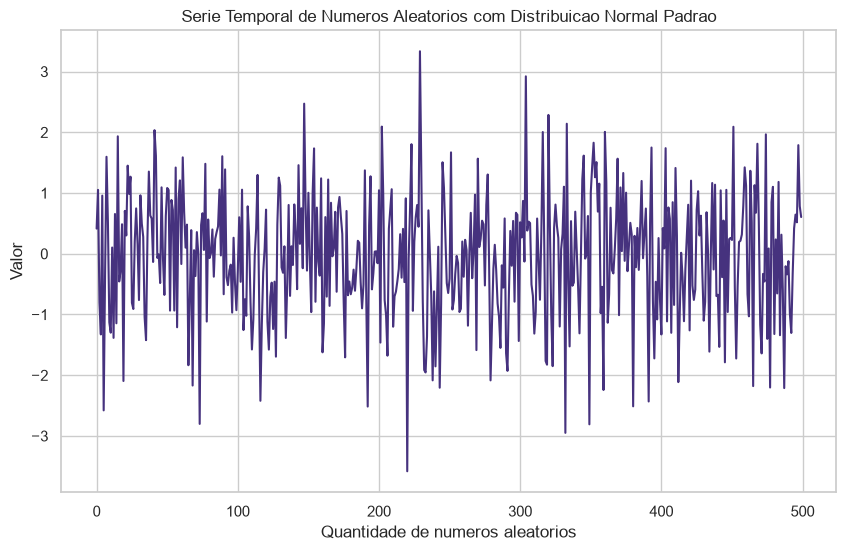

In [71]:
# In[27]: Plotando a serie temporal de numeros aleatorios com distribuicao normal 
# padrao (Selecionar todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(aleat)
plt.title("Serie Temporal de Numeros Aleatorios com Distribuicao Normal Padrao")
plt.xlabel("Quantidade de numeros aleatorios")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

In [72]:
# In[28]: Calculando a media e o desvio padrao
print("Media:", aleat.mean())
print("Desvio padrao:", aleat.std())

Media: -0.046306456573957766
Desvio padrao: 1.036258094285822


In [73]:
# In[29]: Gerando uma serie de numeros aleatorios com media 2 e desvio padrao 0.1
aleat1 = pd.Series(np.random.normal(loc=2, scale=0.1, size=500))

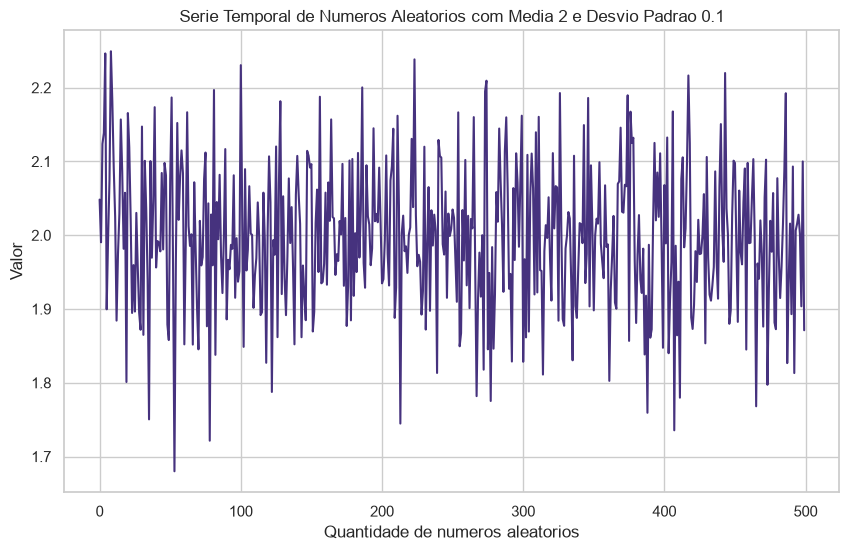

In [74]:
# In[30]: Plotando a serie temporal de numeros aleatorios com media 2 e 
# desvio padrao 0.1 (Selecionar todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(aleat1)
plt.title("Serie Temporal de Numeros Aleatorios com Media 2 e Desvio Padrao 0.1")
plt.xlabel("Quantidade de numeros aleatorios")
plt.ylabel("Valor")
plt.grid(True)
plt.show()


In [75]:
# In[31]: Calculando a media e o desvio padrao
print("Media:", aleat1.mean())
print("Desvio padrao:", aleat1.std())

Media: 1.9971569507020845
Desvio padrao: 0.09857966121952604


###############################################################################
### Trabalhando com uma Serie Temporal de um Passeio Aleatorio
###############################################################################


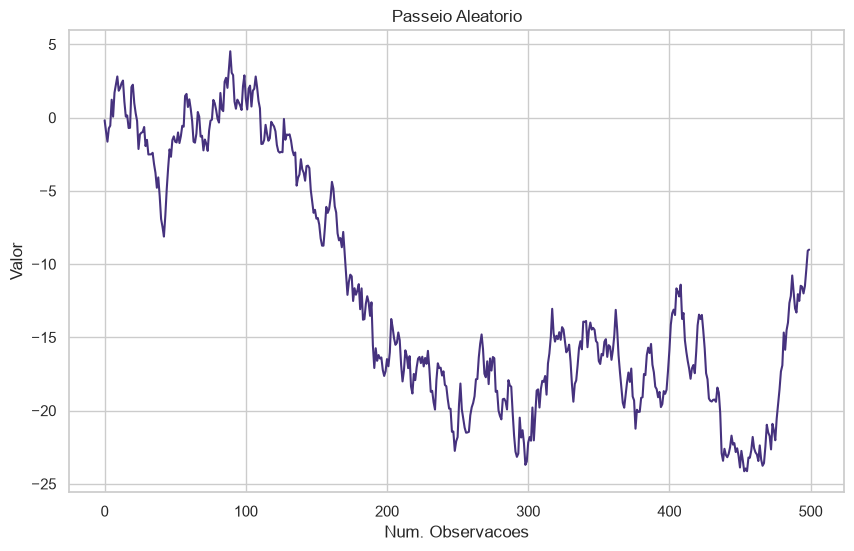

In [76]:
# Gerando numeros aleatorios com distribuicao normal padrao
aleat = pd.Series(np.random.normal(size=500))

# Calculando o passeio aleatorio (soma cumulativa)
passeio = aleat.cumsum()

# In[33]: Plotando o passeio aleatorio (Selecionar todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(passeio)
plt.title("Passeio Aleatorio")
plt.xlabel("Num. Observacoes")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

###############################################################################
### Comparando a Serie PETR4(jan/2020 a jul/2024) com o Passeio Aleatorio
###############################################################################


In [77]:

# Supondo que voce ja tenha os dados da serie temporal `petr4` em um DataFrame
#  ou Serie do pandas
# Vou criar um exemplo simples aqui para a serie petr4

petr4 = basepetr4['fechamento']
print(petr4)

# In[35]: Criando a serie petropasseio com o mesmo tamanho da petr4, inicialmente 
# todos os valores com zero

# Obtendo a quantidade de pontos dinamicamente
n_pontos = petr4.shape[0]

# Criando a Series com o tamanho correto
petropasseio = pd.Series(0.0, index=np.arange(n_pontos))

# Series começam no mesmo ponto
petropasseio.iloc[0] = petr4.iloc[0]

# Gerando o passeio aleatório usando o tamanho dinâmico
for i in range(1, n_pontos):
    petropasseio.iloc[i] = petropasseio.iloc[i - 1] + np.random.normal()

print(petropasseio)


0       30.70
1       30.45
2       30.69
3       30.50
4       30.40
        ...  
1556    48.94
1557    48.51
1558    46.61
1559    47.90
1560    49.03
Name: fechamento, Length: 1561, dtype: float64
0       30.700000
1       30.276890
2       29.909583
3       29.740346
4       30.011057
          ...    
1556   -20.944209
1557   -19.454499
1558   -21.166802
1559   -20.830310
1560   -21.881483
Length: 1561, dtype: float64


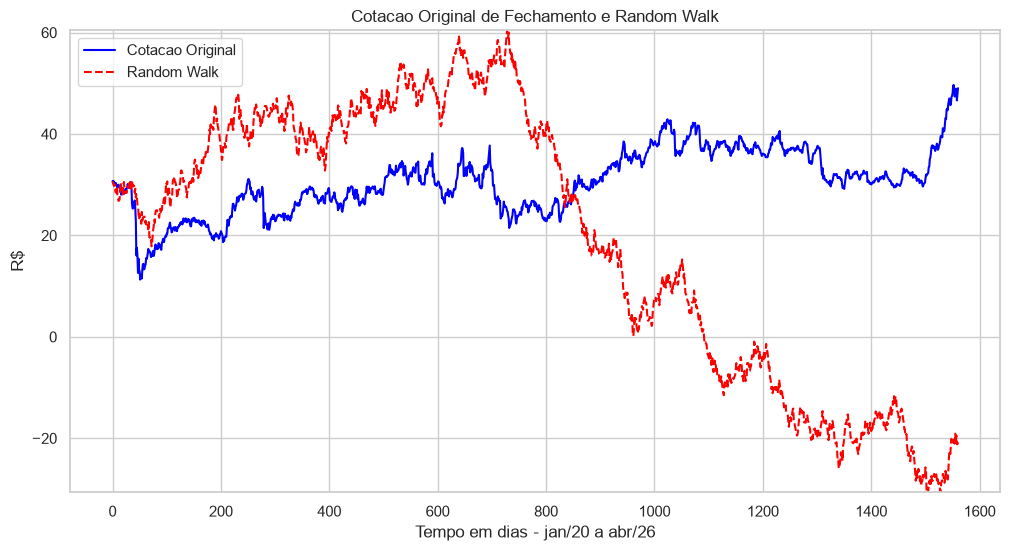

In [78]:
# In[36]: Plotando no mesmo grafico as duas series
plt.figure(figsize=(12, 6))
plt.plot(petr4, label='Cotacao Original', color='blue')
plt.plot(petropasseio, label='Random Walk', linestyle='dashed', color='red')
plt.title("Cotacao Original de Fechamento e Random Walk")
plt.xlabel("Tempo em dias - jan/20 a abr/26")
plt.ylabel("R$")
plt.ylim(min(petropasseio.min(), petr4.min()), max(petropasseio.max(), petr4.max()))
plt.legend(loc='best')
plt.grid(True)
plt.show()

##############################################################################################################################################################
##  DECOMPOSICAO DE SERIES TEMPORAIS
### Comportamento da Covid-19
##############################################################################################################################################################

        Data  total  por_dia
0 2020-02-26      1        1
1 2020-02-27      1        0
2 2020-02-28      1        0
3 2020-02-29      2        1
4 2020-03-01      2        0
        Data  total  por_dia  media_movel
0 2020-02-26      1        1          NaN
1 2020-02-27      1        0          NaN
2 2020-02-28      1        0          NaN
3 2020-02-29      2        1          NaN
4 2020-03-01      2        0          NaN


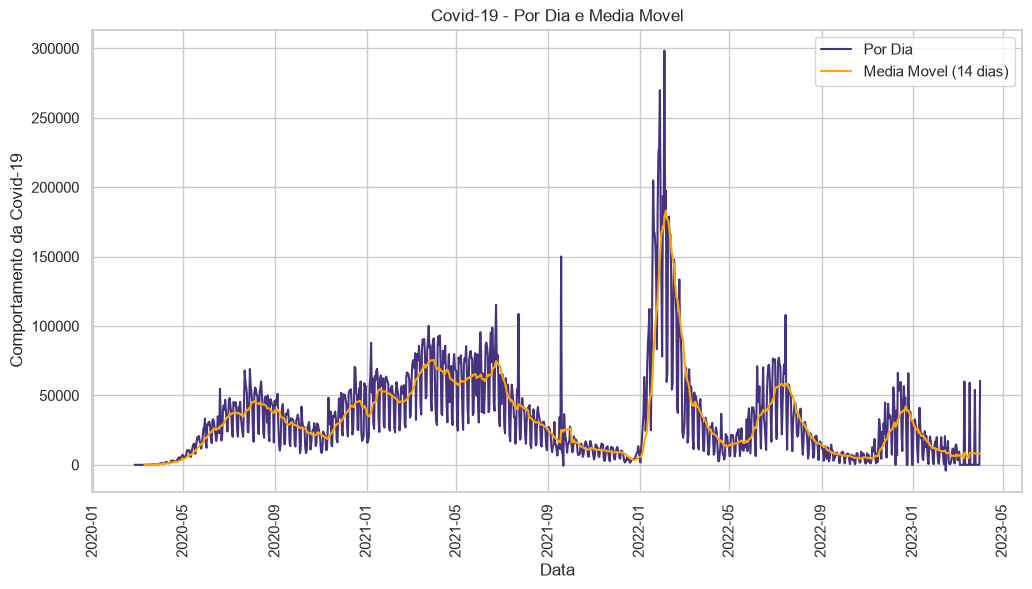

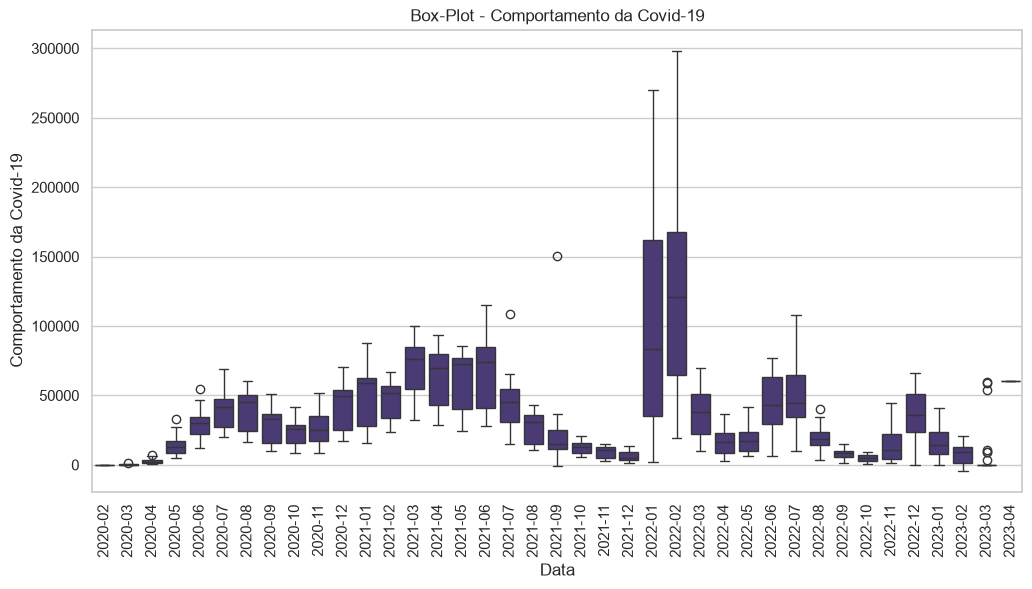

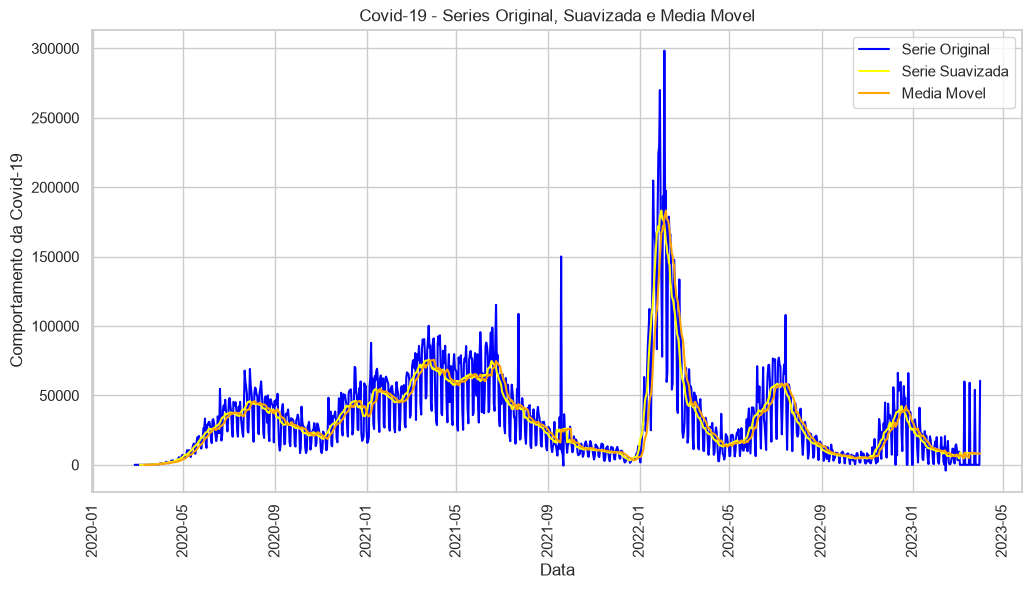

In [79]:

##### Tendencia por medias moveis

# Analisando a serie de casos diarios de COVID 19 Brasil

# lendo a base de dados: Fonte: https://covid.saude.gov.br/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura dos dados
covid = pd.read_excel("covid.xlsx")

print(covid.head())

# In[38]: Transformando a coluna 'Data' em datetime
covid['Data'] = pd.to_datetime(covid['Data'])

# Media movel (14 dias)
covid['media_movel'] = covid['por_dia'].rolling(window=14).mean()

print(covid.head())

# In[39]: Visualizando a serie com as medias moveis (Selecionar todos os comandos)
plt.figure(figsize=(12, 6))
plt.plot(covid['Data'], covid['por_dia'], label='Por Dia')
plt.plot(covid['Data'], covid['media_movel'], label='Media Movel (14 dias)', 
         color='orange')
plt.title('Covid-19 - Por Dia e Media Movel')
plt.xlabel('Data')
plt.ylabel('Comportamento da Covid-19')
plt.legend()
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# In[40]: Box-Plot para verificar se temos outliers (Selecionar todos os comandos)
plt.figure(figsize=(12, 6))
sns.boxplot(x=covid['Data'].dt.to_period('M'), y=covid['por_dia'])
plt.title('Box-Plot - Comportamento da Covid-19')
plt.xlabel('Data')
plt.ylabel('Comportamento da Covid-19')
plt.xticks(rotation=90)
plt.show()

# In[41]: Limpeza dos dados com media movel
covid['covid_suave'] = covid['por_dia'].rolling(window=14, center=True).mean()
covid['media_movel_nao_centralizada'] = covid['por_dia'].rolling(window=14).mean()

# In[42]: Grafico de serie original, serie suavizada e media movel (Selecionar todos 
# os comandos)
plt.figure(figsize=(12, 6))
plt.plot(covid['Data'], covid['por_dia'], label='Serie Original', 
         color='blue')
plt.plot(covid['Data'], covid['covid_suave'], label='Serie Suavizada', 
         color='Yellow')
plt.plot(covid['Data'], covid['media_movel'], label='Media Movel', 
         color='orange')
plt.title('Covid-19 - Series Original, Suavizada e Media Movel')
plt.xlabel('Data')
plt.ylabel('Comportamento da Covid-19')
plt.legend()
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

##############################################################################
### Decomposicao da serie temporal em suas componentes(Tendencia, Sazonal e Residuos)
### Precisamos da biblioteca statsmodels para realizar a decomposicao da serie temporal nos modelos aditivo e multiplicativo alem de plotar seus componentes 
##############################################################################


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# Criar a serie temporal
data = pd.date_range(start='2019-01-01', end='2022-12-31', freq='QE')
values = [10, 14, 8, 25, 16, 22, 14, 35, 15, 27, 18, 40, 28, 40, 25, 65]
s = pd.Series(values[:len(data)], index=data)

print(len(s))
print(s.head())

16
2019-03-31    10
2019-06-30    14
2019-09-30     8
2019-12-31    25
2020-03-31    16
Freq: QE-DEC, dtype: int64


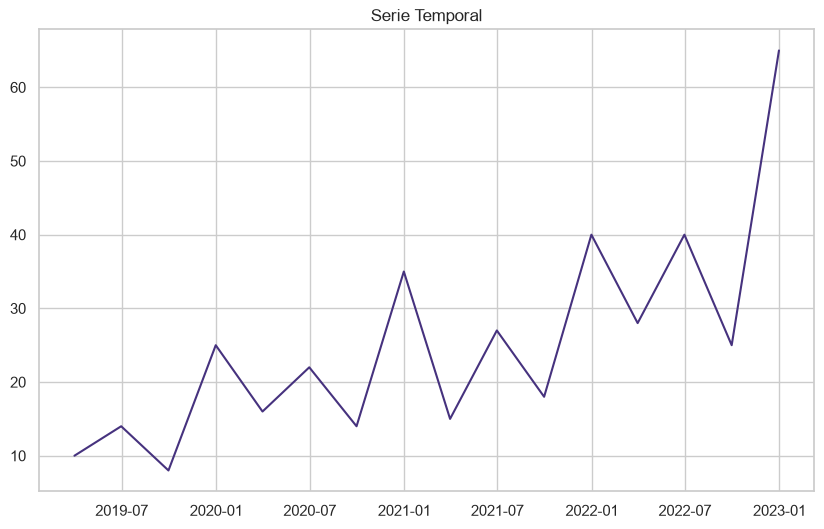

In [81]:
# In[44]: Plotar a serie temporal (Selecionar todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(s)
plt.title('Serie Temporal')
plt.show()

In [82]:
# In[45]: Decomposicao pelo modelo ADITIVO
decompa = seasonal_decompose(s, model='additive', period=4)

# observando os valores da decomposicao pelo modelo aditivo
print(decompa.trend)
print(decompa.seasonal)
print(decompa.resid)

2019-03-31       NaN
2019-06-30       NaN
2019-09-30    15.000
2019-12-31    16.750
2020-03-31    18.500
2020-06-30    20.500
2020-09-30    21.625
2020-12-31    22.125
2021-03-31    23.250
2021-06-30    24.375
2021-09-30    26.625
2021-12-31    29.875
2022-03-31    32.375
2022-06-30    36.375
2022-09-30       NaN
2022-12-31       NaN
Freq: QE-DEC, Name: trend, dtype: float64
2019-03-31    -5.093750
2019-06-30     2.531250
2019-09-30    -7.802083
2019-12-31    10.364583
2020-03-31    -5.093750
2020-06-30     2.531250
2020-09-30    -7.802083
2020-12-31    10.364583
2021-03-31    -5.093750
2021-06-30     2.531250
2021-09-30    -7.802083
2021-12-31    10.364583
2022-03-31    -5.093750
2022-06-30     2.531250
2022-09-30    -7.802083
2022-12-31    10.364583
Freq: QE-DEC, Name: seasonal, dtype: float64
2019-03-31         NaN
2019-06-30         NaN
2019-09-30    0.802083
2019-12-31   -2.114583
2020-03-31    2.593750
2020-06-30   -1.031250
2020-09-30    0.177083
2020-12-31    2.510417
2021-03-3

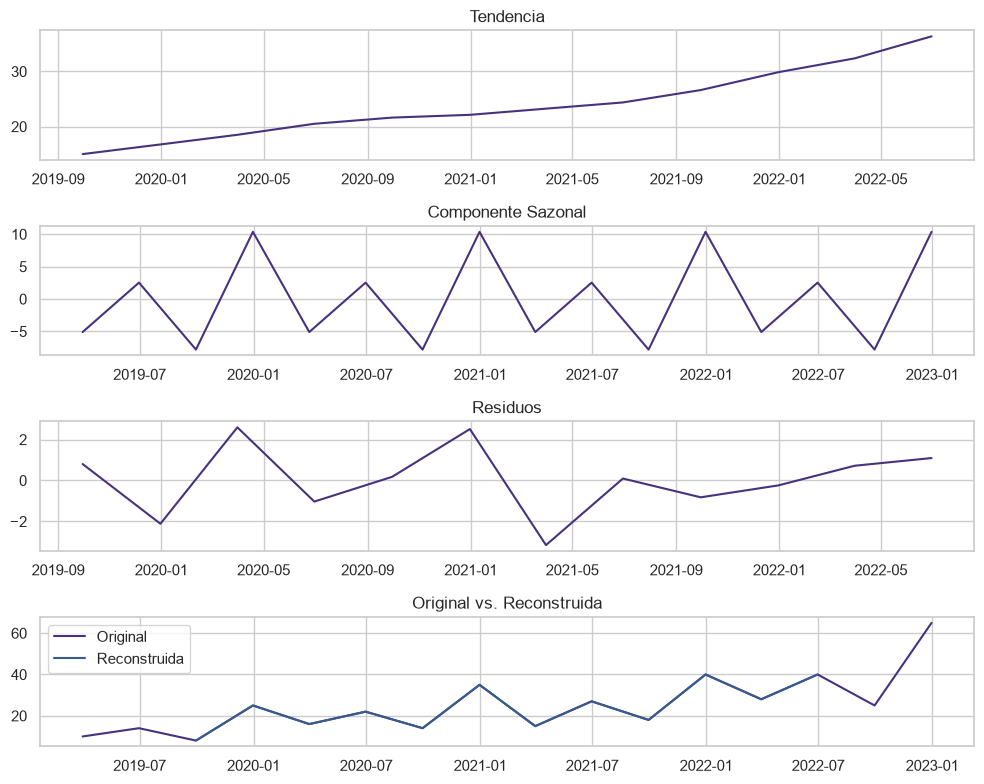

In [83]:
# In[46]: Plotar a decomposicao (Selecionar todos os comandos)
plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
plt.plot(decompa.trend)
plt.title('Tendencia')

plt.subplot(4, 1, 2)
plt.plot(decompa.seasonal)
plt.title('Componente Sazonal')

plt.subplot(4, 1, 3)
plt.plot(decompa.resid)
plt.title('Resi­duos')

plt.subplot(4, 1, 4)
plt.plot(s, label='Original')
plt.plot(decompa.trend + decompa.seasonal + decompa.resid, label='Reconstrui­da')
plt.title('Original vs. Reconstrui­da')
plt.legend()

plt.tight_layout()
plt.show()

##############################################################################################################################################################
### Trabalhando com a serie do PIB do Brasil 
##############################################################################################################################################################

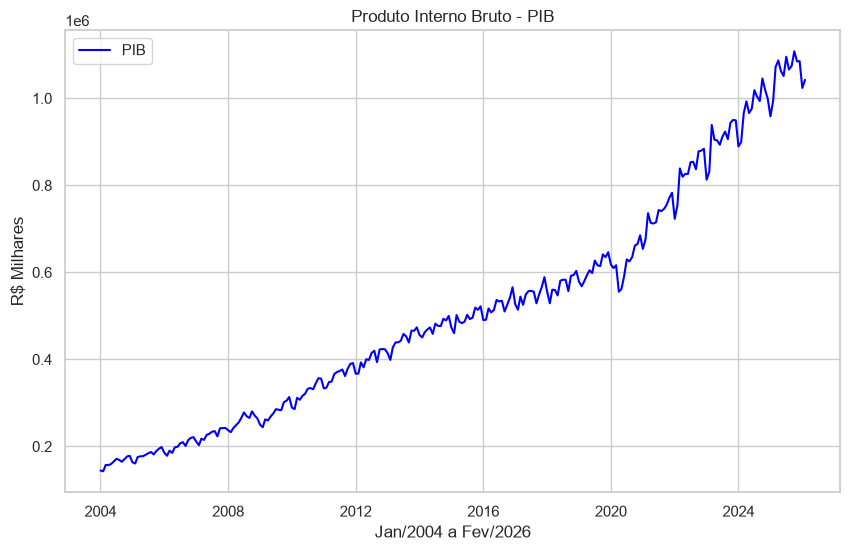

In [84]:
###############################################################################
## Trabalhando com a serie do PIB do Brasil 
######################################################

pib = pd.read_excel("pib_mensal.xlsx", parse_dates=True, index_col=0)
 
# Transformar a base de dados em um objeto de classe ts
pib_ts = pd.Series(pib['pib'].values, index=pib.index)
 
# In[50]: Plotar a serie temporal (Selecionar todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(pib_ts.index, pib_ts.values, label='PIB', color='blue')
plt.title('Produto Interno Bruto - PIB')
plt.xlabel('Jan/2004 a Fev/2026')
plt.ylabel('R$ Milhares')
plt.legend()
plt.show()


### C

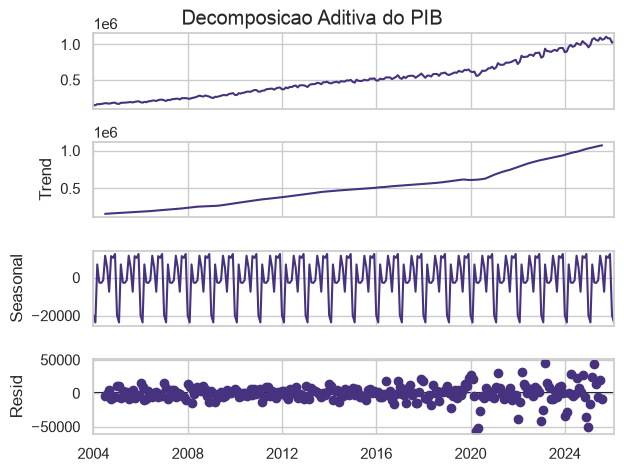

In [85]:

# In[51]: Decompondo o PIB pelo modelo aditivo
decomp_aditivo = seasonal_decompose(pib_ts, model='additive', period=12)

# In[52]: Plotando a decomposicao (Selecionar todos os comandos)
decomp_aditivo.plot()
plt.suptitle('Decomposicao Aditiva do PIB')
plt.show()


### Decompondo o PIB pelo modelo multiplicativo

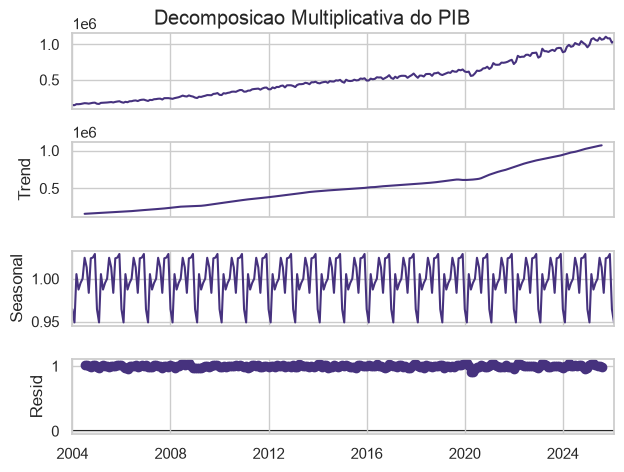

In [86]:

# In[53]: Decompondo o PIB pelo modelo multiplicativo
decomp_multiplicativo = seasonal_decompose(pib_ts, model='multiplicative', 
                                           period=12)

# In[54]: Plotando a decomposicao (Selecionar todos os comandos)
decomp_multiplicativo.plot()
plt.suptitle('Decomposicao Multiplicativa do PIB')
plt.show()


##############################################################################################################################################################
#### Aplicando a decomposicao das series temporais
#### usando a palheta de cores viridis
#### decomposicao da serie temporal do PIB Mensal BR
##############################################################################################################################################################

# Guia de Estudo: Decomposição de Séries Temporais
## Modelos Aditivo vs. Multiplicativo

Na decomposição clássica de séries temporais, o objetivo é isolar os três componentes principais que moldam o comportamento dos dados ao longo do tempo:
1. **Tendência ($T_t$):** A direção de longo prazo da série (crescimento ou declínio).
2. **Sazonalidade ($S_t$):** As flutuações cíclicas que se repetem em intervalos regulares (ex: trimestral, mensal, diário).
3. **Resíduo/Ruído ($R_t$):** A variação aleatória e imprevisível.

A escolha entre o modelo **Aditivo** e o **Multiplicativo** depende puramente de como a **Sazonalidade** interage com a **Tendência**.

---

### Tabela Comparativa

| Característica | Modelo Aditivo | Modelo Multiplicativo |
| :--- | :--- | :--- |
| **Equação Matemática** | $Y_t = T_t + S_t + R_t$ | $Y_t = T_t \times S_t \times R_t$ |
| **Comportamento da Sazonalidade** | **Constante.** A amplitude do zigue-zague não muda se a média subir ou descer. | **Proporcional.** A amplitude cresce ou diminui acompanhando o nível da tendência. |
| **Unidade de Medida** | Mesma unidade da série original (valores absolutos, ex: Reais, Graus, Unidades). | Fator relativo / Proporcional (funciona como uma porcentagem ou multiplicador). |
| **Formato Visual do Gráfico** | **Formato de Tubo:** As linhas que ligam os picos e vales correm paralelas ao longo do tempo. | **Formato de Megafone:** O zigue-zague começa estreito e vai se abrindo (ou vice-versa). |
| **Caso do PIB do Brasil** | **Inadequado.** Subestima as flutuações sazonais recentes e superestima as antigas. | **Ideal.** Captura o fato de que uma variação sazonal hoje movimenta muito mais bilhões do que nos anos 90. |

---

### Entendendo a Diferença com o Exemplo do PIB

O Produto Interno Bruto (PIB) do Brasil possui uma tendência de crescimento a longo prazo e fortes componentes sazonais (como o peso do Agronegócio em determinados trimestres ou o aumento do Comércio no fim do ano).

* **Se aplicássemos o Modelo Aditivo ao PIB:** O modelo assumiria que a safra agrícola ou as festas de fim de ano adicionam um valor fixo em dinheiro (por exemplo, exatos R$ 30 bilhões) todos os anos. Porém, R$ 30 bilhões na década de 1990 representavam um impacto gigante na economia da época, enquanto hoje, em uma economia trilionária, esse valor é percentualmente muito menor. O gráfico real não se comporta assim.
* **Ao aplicarmos o Modelo Multiplicativo ao PIB:** O modelo entende a sazonalidade como uma porcentagem (por exemplo, o 4º trimestre rende sempre `1.05` vezes a tendência atual, ou seja, 5% a mais). Na década de 90, 5% de uma economia menor gerava um salto pequeno em Reais. Hoje, 5% de uma economia trilionária gera um salto de dezenas de bilhões de Reais. O modelo acompanha a expansão da economia.

---

## 🌟 A Regra de Ouro

Para decidir qual modelo aplicar nos seus projetos de ciência de dados, observe o comportamento do zigue-zague (sazonalidade) ao longo do tempo e faça a seguinte pergunta:

> **"O tamanho da variação sazonal depende da altura da tendência?"**

* **NÃO (A variação é um VALOR ABSOLUTO FIXO):** Use o **Modelo Aditivo**.
    * *Exemplo:* Temperatura média diária (o verão é sempre cerca de 12°C mais quente que o inverno, mesmo que a temperatura média global suba um pouco com os anos).
    * *Exemplo:* Queda de braço operacional fixa (ex: uma plataforma recebe sempre cerca de 50 anúncios a menos nos domingos por conta do comportamento de descanso semanal, independentemente do volume total mensal).
* **SIM (A variação é uma TAXA / PORCENTAGEM):** Use o **Modelo Multiplicativo**.
    * *Exemplo:* Séries econômicas e financeiras (PIB, faturamento de empresas, preços de ativos), onde as oscilações sazonais escalam proporcionalmente ao tamanho do mercado ou à inflação.

---

### 💡 Dica de Modelagem (Data Science)
Alguns algoritmos clássicos de séries temporais possuem limitações para trabalhar nativamente com decomposição multiplicativa. Caso se depare com essa situação ao analisar o PIB, a técnica padrão é **aplicar uma transformação logarítmica ($\log(Y_t)$)** na base de dados antes de treinar o modelo. 

O logaritmo transforma relações multiplicativas em aditivas:
$$\log(T_t \times S_t \times R_t) = \log(T_t) + \log(S_t) + \log(R_t)$$

Após realizar as projeções ou a decomposição, basta aplicar a função exponencial ($\exp$) para retornar os valores à escala original em Reais.

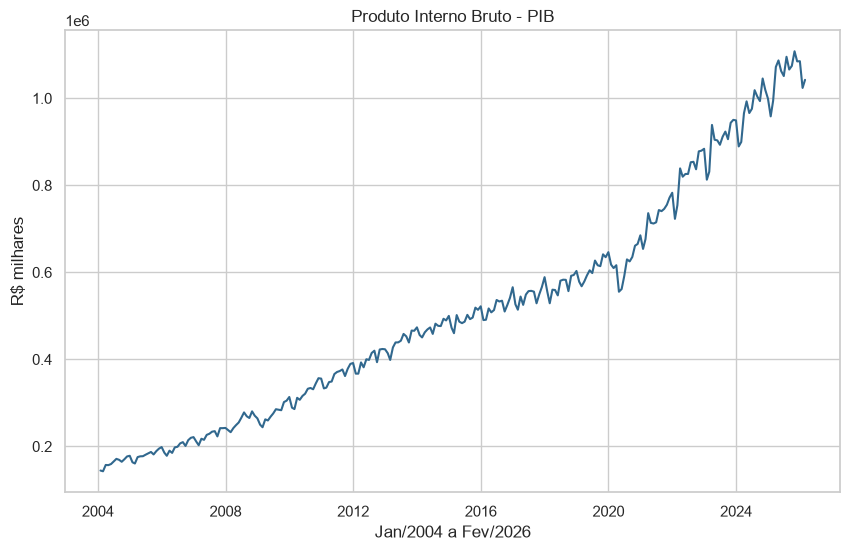

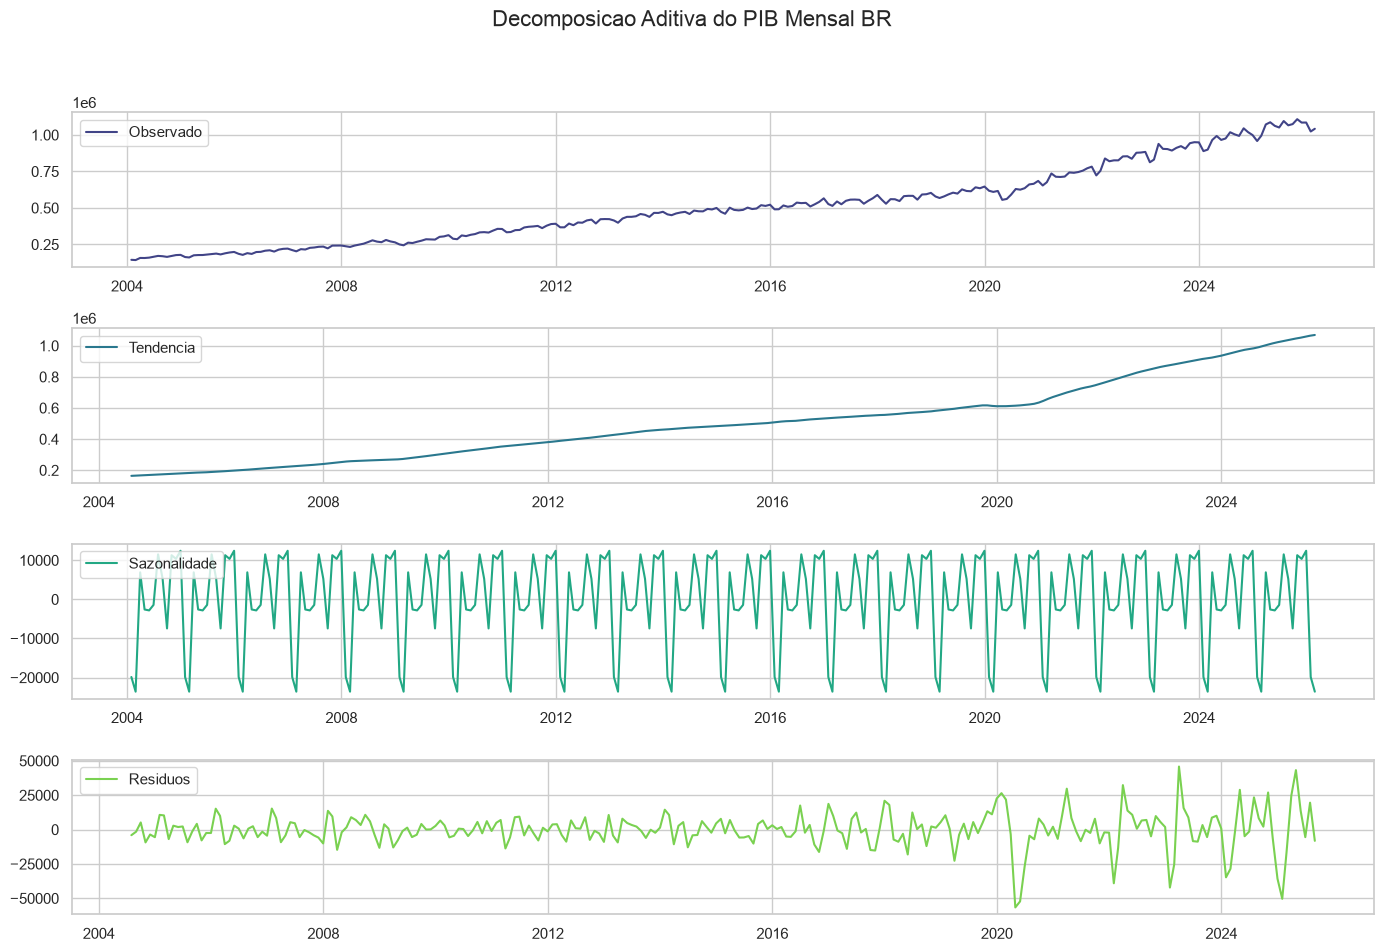

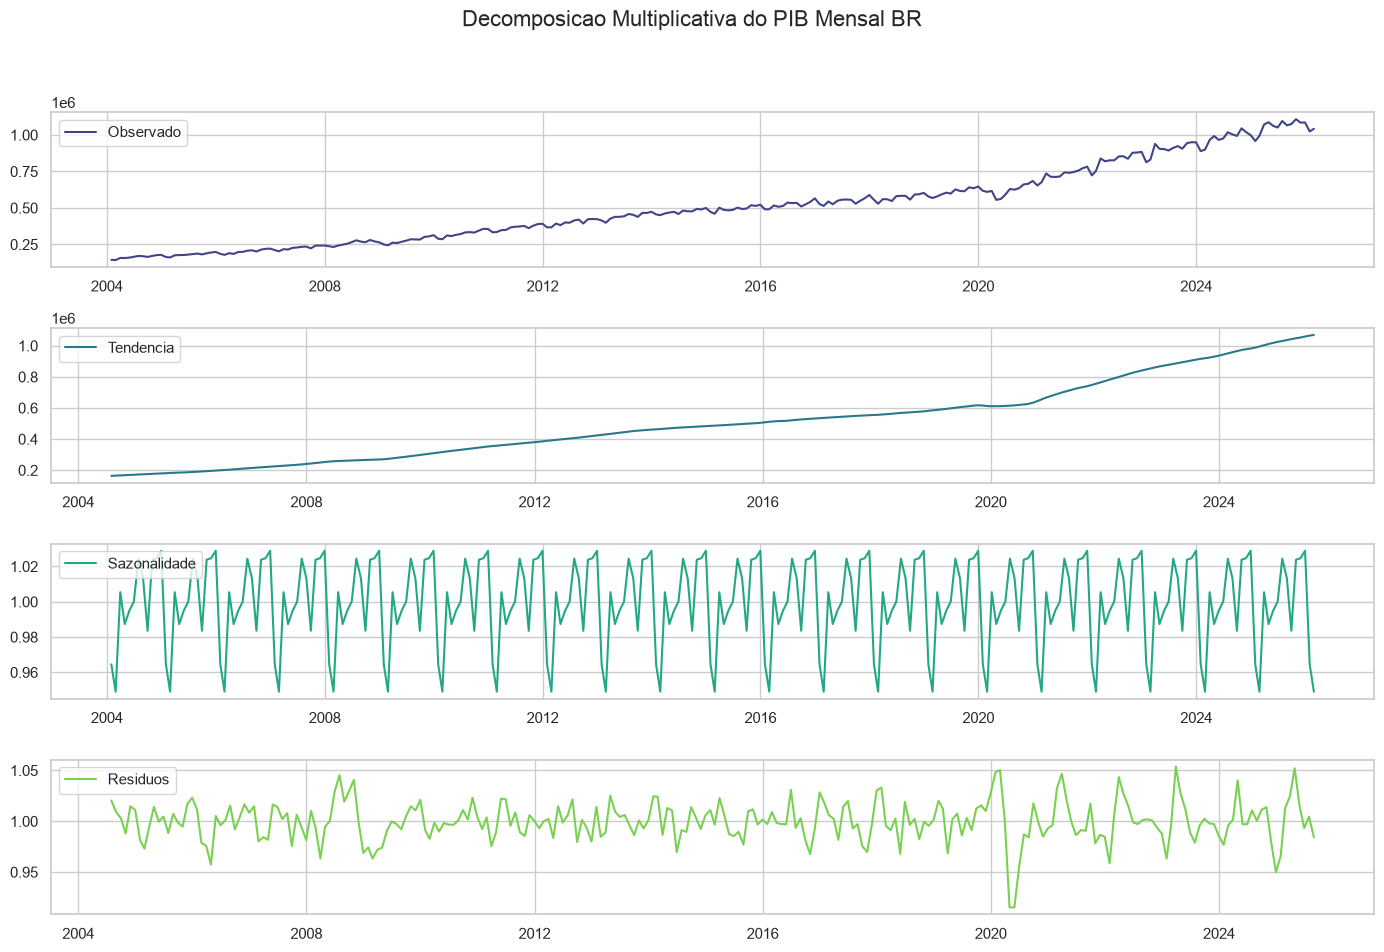

In [87]:

# In[55]:
###############################################################################
##### Aplicando a decomposicao das series temporais
##### usando a palheta de cores viridis
############# decomposicao da serie temporal do PIB Mensal BR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Configurar o estilo dos graficos e a paleta de cores
sns.set(style='whitegrid', palette='viridis')

# Carregar os dados do Excel
pib = pd.read_excel('pib_mensal.xlsx')

# Transformar a base de dados em um objeto de serie temporal (Selecione todos
# os comandos)
pib_ts = pd.Series(pib.iloc[:, 1].values, 
                   index=pd.date_range(start='2004-01-01',
                                       periods=len(pib), freq='ME'))

# In[56]: Fazer a plotagem da serie temporal (Selecione todos os comandos)
plt.figure(figsize=(10, 6))
plt.plot(pib_ts, color=sns.color_palette("viridis", 2)[0])
plt.title('Produto Interno Bruto - PIB')
plt.xlabel('Jan/2004 a Fev/2026')
plt.ylabel('R$ milhares')
plt.show()

# In[57]: Decompor o PIB pelo modelo aditivo
decomp_add = seasonal_decompose(pib_ts, model='additive', period=12)

# Decompor o PIB pelo modelo multiplicativo
decomp_mul = seasonal_decompose(pib_ts, model='multiplicative', period=12)

# In[58]: Funcao para plotar decomposicao (Selecionar todos os comandos)
def plot_decomposition(decomposition, title):
    colors = sns.color_palette("viridis", 4)
    
    plt.figure(figsize=(14, 10))
    plt.suptitle(title, fontsize=16)

    plt.subplot(411)
    plt.plot(decomposition.observed, label='Observado', color=colors[0])
    plt.legend(loc='upper left')
    plt.grid(True)

    plt.subplot(412)
    plt.plot(decomposition.trend, label='Tendencia', color=colors[1])
    plt.legend(loc='upper left')
    plt.grid(True)

    plt.subplot(413)
    plt.plot(decomposition.seasonal, label='Sazonalidade', color=colors[2])
    plt.legend(loc='upper left')
    plt.grid(True)

    plt.subplot(414)
    plt.plot(decomposition.resid, label='Residuos', color=colors[3])
    plt.legend(loc='upper left')
    plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# In[59]: Plotar decomposicao aditiva
plot_decomposition(decomp_add, 'Decomposicao Aditiva do PIB Mensal BR')

# Plotar decomposicao multiplicativa
plot_decomposition(decomp_mul, 'Decomposicao Multiplicativa do PIB Mensal BR')


##############################################################################################################################################################

## Estatisticas de Acuracia das previsoes

##############################################################################################################################################################

# Comparativo Resumido das Métricas de Erro

Com base nos seus dados:
* **Valores Reais:** `[1, 2, 3, 5, 6, 8, 9]`
* **Valores Previstos:** `[1, 3, 3, 4, 6, 7, 9]`

### 📊 Tabela Comparativa Direta

| Métrica | Sigla | Seu Resultado | Foco Principal | Como Trata os Sinais? | Comportamento com Erros Grandes |
| :--- | :---: | :---: | :--- | :--- | :--- |
| **Erro Médio** | **ME** | `0.14` | **Viés (Bias)** do modelo | Mantém os sinais (`+` e `-`) | Erros positivos e negativos se cancelam. |
| **Erro Absoluto Médio** | **MAE** | `0.42` | **Magnitude real** do erro | Transforma tudo em positivo (`|erro|`) | Trata todos os erros de forma linear. |
| **Erro Quadrático Médio** | **MSE** | `0.42` | **Penalização** de outliers | Transforma tudo em positivo (`erro²`) | Pune severamente erros grandes. |

---

### 🔍 Resumo Objetivo (Para que serve cada uma?)

1. **Erro Médio (ME):** * **Objetivo:** Descobrir a *direção* do erro (se o modelo está "viciado").
   * **Interpretação:** Um valor próximo de zero indica que o modelo erra equilibradamente para cima e para baixo. O seu resultado (`0.14`) mostra um leve viés de **subestimar** (as previsões são ligeiramente menores que os reais).

2. **Erro Absoluto Médio (MAE):** * **Objetivo:** Descobrir o *tamanho* real do erro médio em unidades diretas.
   * **Interpretação:** Responde à pergunta de negócio: "Em média, por quanto o modelo erra?". O seu modelo erra, em média, por **0.42 unidades** para cada previsão.

3. **Erro Quadrático Médio (MSE):** * **Objetivo:** Detectar e *punir erros bizarros* ou discrepantes (outliers).
   * **Interpretação:** Como eleva o erro ao quadrado, se o modelo cometer um erro grande (ex: errar por 10), o peso desse erro vira 100. No seu exemplo, deu exatamente igual ao MAE (`0.42`) porque todos os seus erros foram pequenos (no máximo 1 unidade, e $1^2 = 1$). Se houvesse um único erro grande, o MSE teria disparado.

In [88]:
###############################################################################
### Estatisticas de Acuracia das previsoes
###############################################################################

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import root_mean_squared_error  # Substitui o squared=False
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# Dados de exemplo (Reais vs. Previstos)
reais = np.array([1, 2, 3, 5, 6, 8, 9])
previstos = np.array([1, 3, 3, 4, 6, 7, 9])

print("Reais:", reais)
print("----------------------")
print("Previstos:", previstos)


Reais: [1 2 3 5 6 8 9]
----------------------
Previstos: [1 3 3 4 6 7 9]


In [89]:

# 1. Erro Simples (Resíduos)
# Útil para verificar se o modelo tende a superestimar ou subestimar
erro = reais - previstos
print("Erro Simples (Resíduos):", erro)

Erro Simples (Resíduos): [ 0 -1  0  1  0  1  0]


In [90]:

# 2. Erro Médio (ME)
# Indica o viés (bias) do modelo
merror = np.mean(erro)
print(f"Erro Médio (ME): {merror}")

Erro Médio (ME): 0.14285714285714285


In [91]:

# 3. Erro Absoluto Médio (MAE)
# Mede a magnitude média do erro sem considerar direção [cite: 19]
mae = mean_absolute_error(reais, previstos)
print(f"Erro Absoluto Médio (MAE): {mae}")


Erro Absoluto Médio (MAE): 0.42857142857142855


In [92]:

# 4. Erro Quadrático Médio (MSE)
# Penaliza erros grandes devido ao quadrado
mse = mean_squared_error(reais, previstos)
print(f"Erro Quadrático Médio (MSE): {mse}")

Erro Quadrático Médio (MSE): 0.42857142857142855


In [93]:

# 5. Raiz do Erro Quadrático Médio (RMSE)
# Traz o erro de volta para a unidade original dos dados [cite: 22]
# Se o seu sklearn for < 1.4, use: np.sqrt(mean_squared_error(reais, previstos))
rmse = root_mean_squared_error(reais, previstos)
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse}")  

Raiz do Erro Quadrático Médio (RMSE): 0.6546536707079771


In [94]:

# 6. Erro Percentual Médio (MPE)
# Mostra o desvio médio em termos percentuais
mpe = np.mean((reais - previstos) / reais) * 100
print(f"Erro Percentual Médio (MPE): {mpe:.2f}%")


Erro Percentual Médio (MPE): -2.50%


In [95]:

# 7. Erro Absoluto Percentual Médio (MAPE)
# Muito usado em finanças para medir a precisão em % [cite: 303-306]
mape = mean_absolute_percentage_error(reais, previstos) * 100

# Exibição dos Resultados
print(f"Erro Médio (BIAS): {merror:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MPE: {mpe:.4f}%")
print(f"MAPE: {mape:.4f}%")

Erro Médio (BIAS): 0.1429
MAE: 0.4286
MSE: 0.4286
RMSE: 0.6547
MPE: -2.5000%
MAPE: 11.7857%


###########################################################################################################################
### Calculo do Coeficiente U de Theil
### Funcao para calculo do Coeficiente U de Theil (selecionar todos os comandos)
###########################################################################################################################

In [96]:
# In[61]: Calculo do Coeficiente U de Theil
# Funcao para calculo do Coeficiente U de Theil (selecionar todos os comandos)

def division(measure, previousI):
  return measure / previousI

def power(measure):
  return np.power(measure, 2)

def summation(measure):
  return np.sum(measure)

def mean(N, measure):
  return (1/N) * measure

def sqrt(measure):
  return np.sqrt(measure)

def computeTheilU2(y_true, y_pred):
    N = len(y_true)
    
    subtractionNumerator = y_pred[1:] - y_true[1:]
    divisionNumerator = division(subtractionNumerator, y_true[:-1])
    powerNumerator = power(divisionNumerator)
    summationNumerator = summation(powerNumerator)
    meanNumerator = mean(N, summationNumerator)
    numerator = sqrt(meanNumerator)
    
    subtractionDenominator = y_true[1:] - y_true[:-1]
    powerDenominator = power(division(subtractionDenominator, y_true[:-1]))
    denominator = sqrt(mean(N, summation(powerDenominator)))
        
    theilU2 = numerator / denominator
    
    return theilU2

theil = computeTheilU2(reais,previstos)

theil

# In[62]: Exibir as metricas de acuracia (Selecione todos os comandos)
print(" Indicadores de Acuracia")
print(f'ME - Mean Error: {merror:.2f}')
print(f'MAE - Mean Absolute Error: {mae:.2f}')
print(f'RMSE - Raiz Quadrada do Erro Medio: {rmse:.2f}')
print(f'MPE - Mean Percentage Error: {mpe:.2f}')
print(f'MAPE - Mean Absolute Percentage Error: {mape:.2f}')
print(f'THEIL_U - Theils Inequality Coefficient: {theil:.4f}')



 Indicadores de Acuracia
ME - Mean Error: 0.14
MAE - Mean Absolute Error: 0.43
RMSE - Raiz Quadrada do Erro Medio: 0.65
MPE - Mean Percentage Error: -2.50
MAPE - Mean Absolute Percentage Error: 11.79
THEIL_U - Theils Inequality Coefficient: 0.7823
